In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load Data

In [4]:
df = pd.read_csv("diabetes_prediction_dataset.csv")
print(df.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


# Step 2: Basic Data Analysis

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [10]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [9]:
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [12]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [13]:
df[['age', 'bmi']].describe()

,age,bmi
count,100000.000000,100000.000000
mean,41.885856,27.320767
std,22.516840,6.636783
min,0.080000,10.010000
25%,24.000000,23.630000
50%,43.000000,27.320000
75%,60.000000,29.580000
max,80.000000,95.690000


In [14]:
print("Mean:", df['age'].mean())
print("Std:", df['age'].std())
print("Min:", df['age'].min())
print("Max:", df['age'].max())

Mean: 41.885856
Std: 22.51683987161513
Min: 0.08
Max: 80.0


In [15]:
print("Mean:", df['bmi'].mean())
print("Std:", df['bmi'].std())
print("Min:", df['bmi'].min())
print("Max:", df['bmi'].max())

Mean: 27.3207671
Std: 6.636783416649581
Min: 10.01
Max: 95.69


# Step 3: Data Visualization

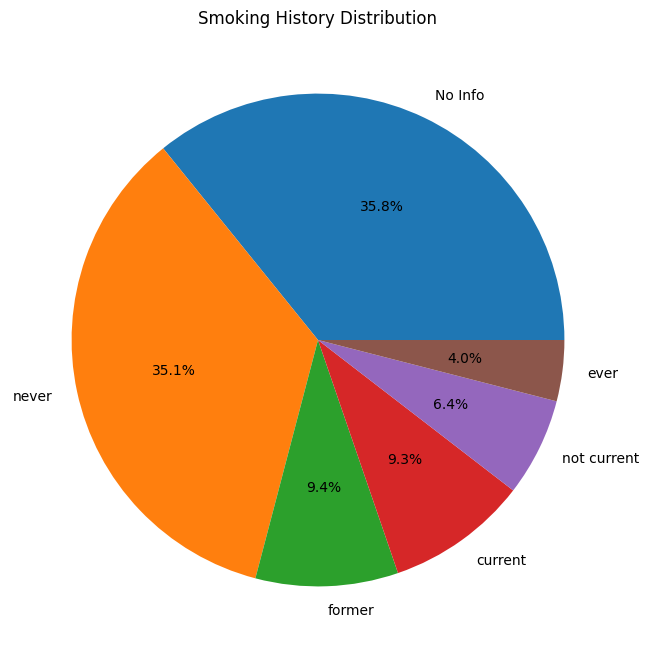

In [17]:
smoke_counts = df['smoking_history'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    smoke_counts,
    labels=smoke_counts.index,
    autopct='%1.1f%%',
)
plt.title("Smoking History Distribution")
plt.show()


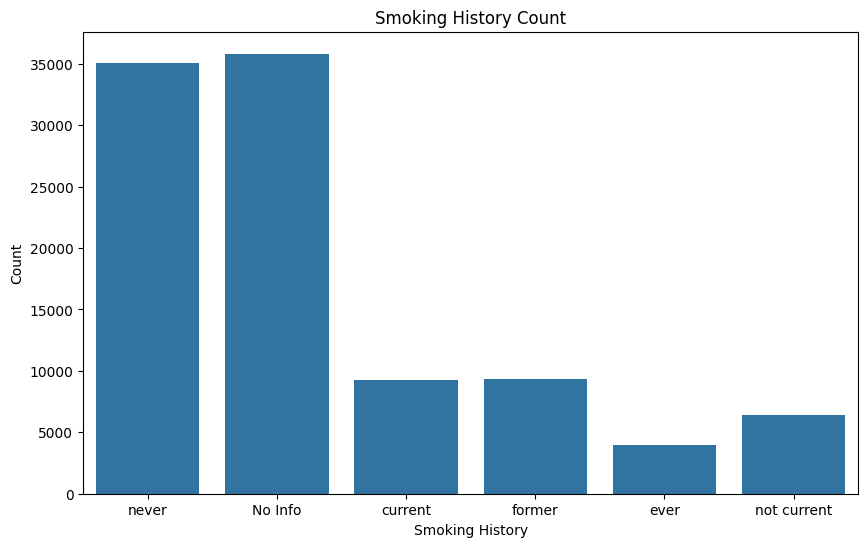

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(
    x='smoking_history',
    data=df
)

plt.title("Smoking History Count")
plt.xlabel("Smoking History")
plt.ylabel("Count")
plt.show()

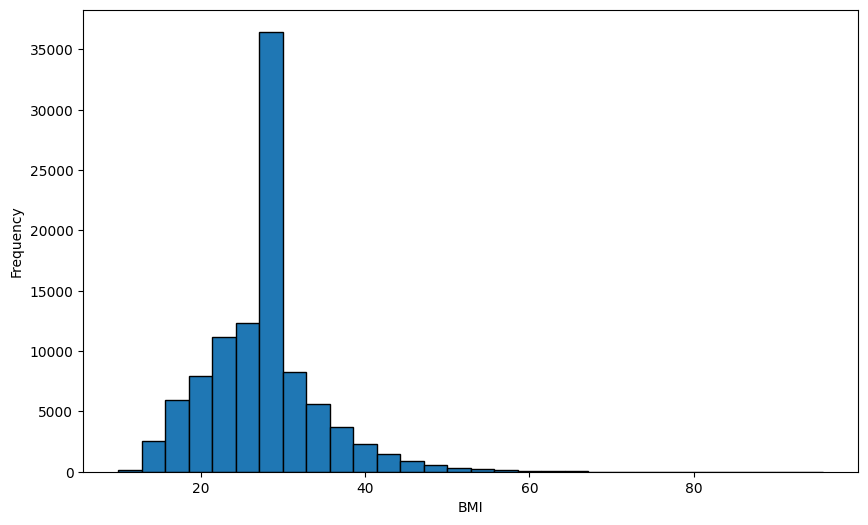

In [27]:
plt.figure(figsize=(10,6))
plt.hist(df['bmi'], bins=30, edgecolor = 'black')

plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()

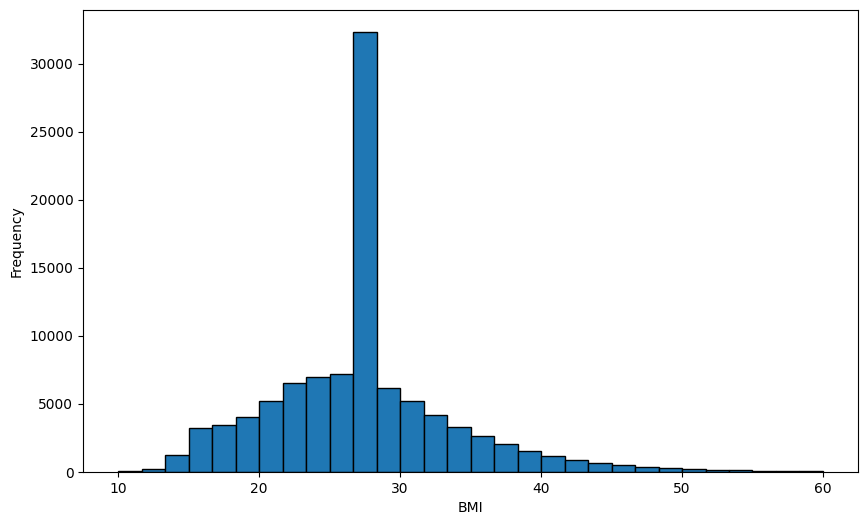

In [29]:
bmi_less_60 = df[df['bmi'] < 60]

plt.figure(figsize=(10,6))
plt.hist(
    bmi_less_60['bmi'],
    bins=30,
    edgecolor='black'
)

plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()


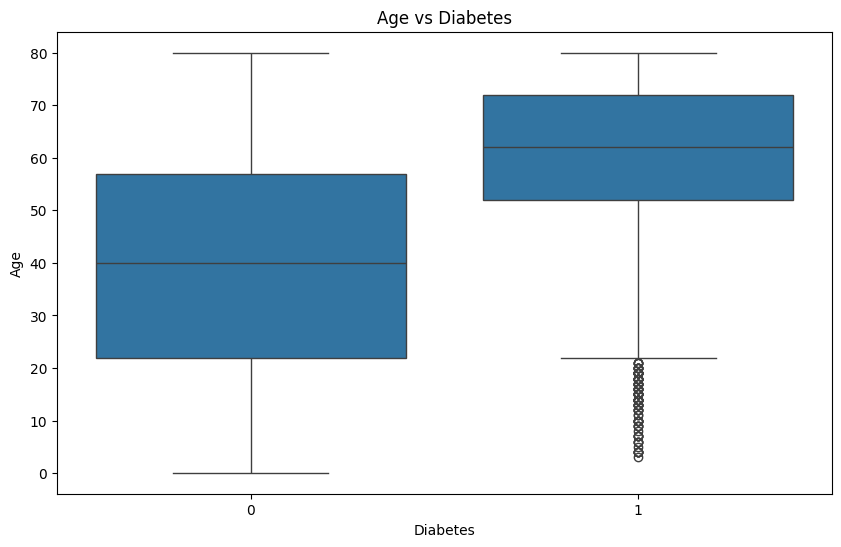

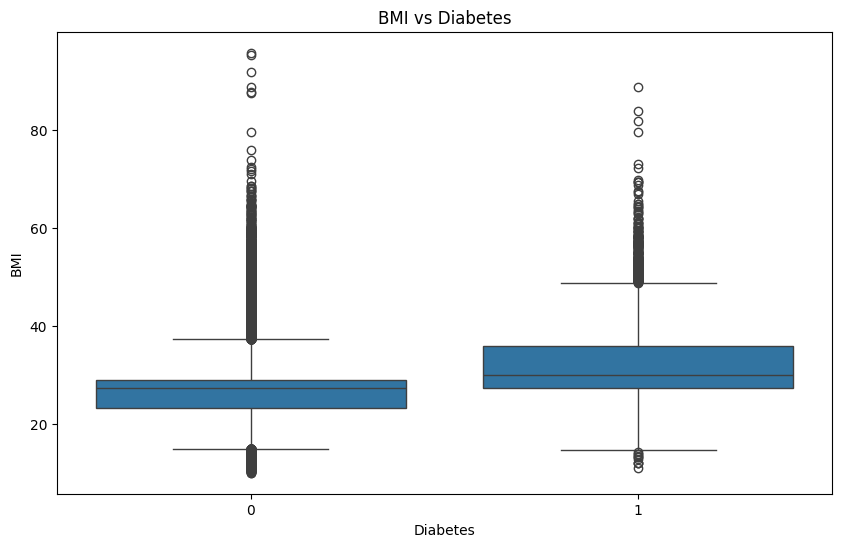

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(x='diabetes', y='age', data=df)

plt.title("Age vs Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Age")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='diabetes', y='bmi', data=df)

plt.title("BMI vs Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("BMI")
plt.show()

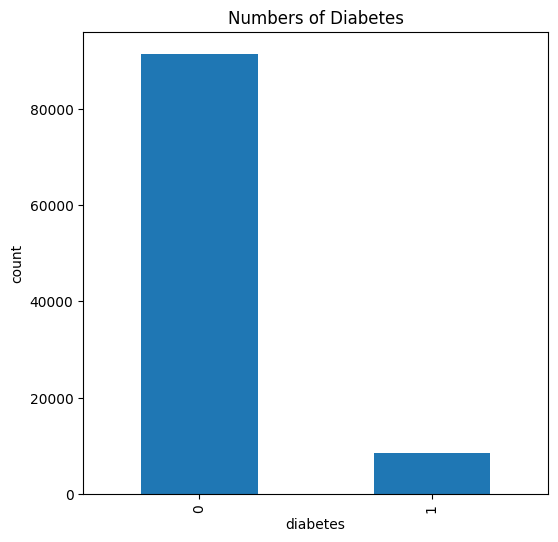

In [34]:
plt.figure(figsize=(6,6))

df['diabetes'].value_counts().plot(kind='bar')

plt.title("Numbers of Diabetes")
plt.xlabel("diabetes")
plt.ylabel("count")

plt.show()

# Step 4: Data Processing

In [37]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['gender_encoded'] = le.fit_transform(df['gender'])

df.head(2)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_encoded
0,Female,80.0,0,1,never,25.19,6.6,140,0,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,0


In [38]:
print(df.head(2))

hist_map = {
    'never': 0,
    'No Info': 2,
    'current': 10,
    'former': 8,
    'ever': 20,
    'not current': 5
}

# Apply mapping and get new columns
df['smoking_hist'] = df['smoking_history'].map(hist_map)

df.head(2)

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   

   HbA1c_level  blood_glucose_level  diabetes  gender_encoded  
0          6.6                  140         0               0  
1          6.6                   80         0               0  


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_encoded,smoking_hist
0,Female,80.0,0,1,never,25.19,6.6,140,0,0,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0,0,2


In [39]:
category_cols = ['gender', 'smoking_history']

df_use_dummies = pd.get_dummies(
    df,
    columns=category_cols,
    dtype=int
)

print("--------")
print(df_use_dummies.dtypes)

df_use_dummies.head(2)

--------
age                            float64
hypertension                     int64
heart_disease                    int64
bmi                            float64
HbA1c_level                    float64
blood_glucose_level              int64
diabetes                         int64
gender_encoded                   int64
smoking_hist                     int64
gender_Female                    int64
gender_Male                      int64
gender_Other                     int64
smoking_history_No Info          int64
smoking_history_current          int64
smoking_history_ever             int64
smoking_history_former           int64
smoking_history_never            int64
smoking_history_not current      int64
dtype: object


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_encoded,smoking_hist,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,0,0,1,0,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,0,2,1,0,0,1,0,0,0,0,0


In [41]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

encoded = ohe.fit_transform(df[['gender']])

encoded_df = pd.DataFrame(
    encoded.toarray(),
    columns=ohe.get_feature_names_out(['gender'])
)

print(encoded_df)

       gender_Female  gender_Male  gender_Other
0                1.0          0.0           0.0
1                1.0          0.0           0.0
2                0.0          1.0           0.0
3                1.0          0.0           0.0
4                0.0          1.0           0.0
...              ...          ...           ...
99995            1.0          0.0           0.0
99996            1.0          0.0           0.0
99997            0.0          1.0           0.0
99998            1.0          0.0           0.0
99999            1.0          0.0           0.0

[100000 rows x 3 columns]


# Step 5: Seperate Data Feature and Target

In [42]:
print(df.columns)

col_used = [
    'gender', 'age', 'hypertension', 'heart_disease', 'smoking_hist',
    'HbA1c_level', 'blood_glucose_level'
]

data = df[col_used]

target = df['diabetes']

print(data.shape)
print(target.shape)
print(target.head(2))
data.head(3)

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes',
       'gender_encoded', 'smoking_hist'],
      dtype='object')
(100000, 7)
(100000,)
0    0
1    0
Name: diabetes, dtype: int64


,gender,age,hypertension,heart_disease,smoking_hist,HbA1c_level,blood_glucose_level
0,Female,80.0,0,1,0,6.6,140
1,Female,54.0,0,0,2,6.6,80
2,Male,28.0,0,0,0,5.7,158


# Step 6: Training 3 Classifiers

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)



X = pd.get_dummies(data, drop_first=True)


y = target


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
k_values = [3, 5, 7]

for k in k_values:

    print(f"\n----- K = {k} -----")

    knn = KNeighborsClassifier(n_neighbors=k)


    knn.fit(X_train_scaled, y_train)


    y_pred_knn = knn.predict(X_test_scaled)


    print("Accuracy:", accuracy_score(y_test, y_pred_knn))


    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_knn))


    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_knn))



----- K = 3 -----
Accuracy: 0.96005

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.85      0.64      0.73      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.82      0.86     20000
weighted avg       0.96      0.96      0.96     20000

Confusion Matrix:
[[18106   186]
 [  613  1095]]

----- K = 5 -----
Accuracy: 0.96395

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.92      0.63      0.75      1708

    accuracy                           0.96     20000
   macro avg       0.94      0.81      0.86     20000
weighted avg       0.96      0.96      0.96     20000

Confusion Matrix:
[[18201    91]
 [  630  1078]]

----- K = 7 -----
Accuracy: 0.964

Classification Report:
              precision    recall  f1-score   support

           0

In [47]:
dt = DecisionTreeClassifier(random_state=42)


dt.fit(X_train, y_train)


y_pred_dt = dt.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))


Accuracy: 0.9566

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18292
           1       0.75      0.74      0.74      1708

    accuracy                           0.96     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.96      0.96      0.96     20000

Confusion Matrix:
[[17874   418]
 [  450  1258]]


In [48]:
svm = SVC(kernel='rbf')


svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)


print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.9614

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     18292
           1       0.99      0.55      0.71      1708

    accuracy                           0.96     20000
   macro avg       0.98      0.78      0.84     20000
weighted avg       0.96      0.96      0.96     20000

Confusion Matrix:
[[18283     9]
 [  763   945]]


# Step 7: Finish Table

In [50]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score


def evaluate_model(name, y_test, y_pred):

    cm = confusion_matrix(y_test, y_pred)

    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]
    TP = cm[1][1]

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n{name}")
    print("TP =", TP)
    print("FP =", FP)
    print("TN =", TN)
    print("FN =", FN)
    print("Precision =", precision)
    print("Recall =", recall)
    print("F1-score =", f1)
    print("Accuracy =", accuracy)


# KNN k=3
evaluate_model("KNN (k=3)", y_test, y_pred_knn)

# Decision Tree
evaluate_model("Decision Tree", y_test, y_pred_dt)

# SVM
evaluate_model("SVM", y_test, y_pred_svm)


KNN (k=3)
TP = 1058
FP = 70
TN = 18222
FN = 650
Precision = 0.9379432624113475
Recall = 0.6194379391100703
F1-score = 0.7461212976022567
Accuracy = 0.964

Decision Tree
TP = 1258
FP = 418
TN = 17874
FN = 450
Precision = 0.7505966587112172
Recall = 0.7365339578454333
F1-score = 0.7434988179669031
Accuracy = 0.9566

SVM
TP = 945
FP = 9
TN = 18283
FN = 763
Precision = 0.9905660377358491
Recall = 0.5532786885245902
F1-score = 0.709992486851991
Accuracy = 0.9614
